# Lab 3
- **Student Name**: Daniel Alejandro Castillo Martin
- **Student ID**: N10019284
- **Course:** Advanced Deep Learning - AIGC-5500-0NA
- **Professor**: Hossein Pourmodheji
---

## 1. Imports and Setup

In [115]:
# Import required libraries
import time
import copy
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchvision import models

print('PyTorch Version:', torch.__version__)
print('TorchVision Version:', torchvision.__version__)

PyTorch Version: 2.14.1+cpu
TorchVision Version: 0.29.1+cpu


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [4]:
# Set reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Set seed for cuda devices
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 2. Data Preparation and Exploration

### 2.1 Data Extraction and Initial Exploration

For this lab CIFAR-10 image classification has been selected. It contains 10 categories of objects and animals. A balanced subset will then be selected to keep training manageable on CPU. Both approaches will use the same training and validation images to maintain a controlled comparison.

In [ ]:
# Download dataset
raw_data = datasets.CIFAR10(
    root = './data',
    train = True,
    download = True,
    transform = None
)

100.0%


In [14]:
# Obtain relevant data from the images
classes = raw_data.classes
num_classes = len(classes)
image, label = raw_data[0]

# Initial data exploration
print('Number of Images:', len(raw_data))
print('Number of Classes:', len(classes))
print('Classes:', classes)

Number of Images: 50000
Number of Classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


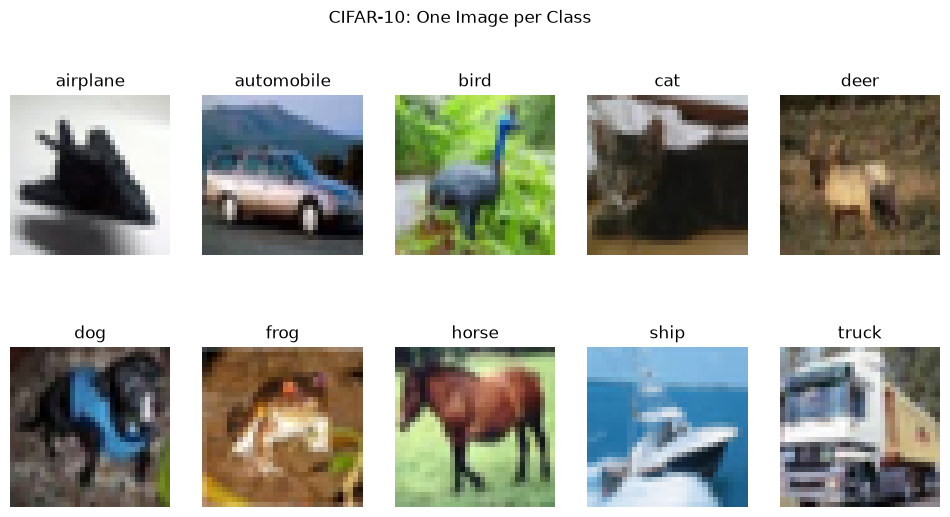

In [30]:
# Display the first example of each of the classes
targets = np.array(raw_data.targets)

fig, axes = plt.subplots(2, 5, figsize = (12, 6))

# Iterate over unique images and labels
for id, ax in enumerate(axes.flat):
    image_index = np.flatnonzero(targets == id)[0]
    image, label = raw_data[int(image_index)]

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis('off')

fig.suptitle('CIFAR-10: One Image per Class')

plt.show()

### 2.2 Balanced Training and Validation Split

The following split is generated for the training and validation sets (we have a total of **1,000 images**):
- **Training set**: 100 images from each class
- **Validation set**: 30 images from each class

The selection uses a fixed random seed, and the two subsets do not overlap. Both training approaches will use these same subsets.

In [34]:
# Constants for train and validation size per class
TRAIN_SIZE = 100
VAL_SIZE = 30

# Create a random generator for the split
rng = np.random.default_rng(42)

# Initialize empty list for train and validation indices
train_indices = []
val_indices = []

for class_id in range(num_classes):
    # Find images that belong to the current class
    class_indices = np.flatnonzero(targets == class_id)

    # Shuffle indices for reproducibility
    shuffled_indices = rng.permutation(class_indices)

    # Select separate training and validation images
    train_indices.extend(shuffled_indices[: TRAIN_SIZE])
    val_indices.extend(shuffled_indices[TRAIN_SIZE : TRAIN_SIZE + VAL_SIZE])

# Convert lists to arrays and mix the class order
train_indices = rng.permutation(np.array(train_indices))
val_indices = rng.permutation(np.array(val_indices))

# Print the sizes and validate that no images overlap
print('Training images:', len(train_indices))
print('Validation images:', len(val_indices))
print('Overlapping images:',len(np.intersect1d(train_indices, val_indices)))

Training images: 1000
Validation images: 300
Overlapping images: 0


In [56]:
# Check that indices are unique and the subsets do not overlap
assert len(np.unique(train_indices)) == len(train_indices)
assert len(np.unique(val_indices)) == len(val_indices)
assert len(np.intersect1d(train_indices, val_indices)) == 0

# Count how many images each class contributes
train_counts = np.bincount(targets[train_indices], minlength = num_classes)
val_counts = np.bincount(targets[val_indices], minlength = num_classes)

assert np.all(train_counts == TRAIN_SIZE)
assert np.all(val_counts == VAL_SIZE)

# Print table with counts of each of the classes and subsets
print(f"{'Class':<15} {'Training':>10} {'Validation':>12}")
print("-" * 40)

for class_id, class_name in enumerate(classes):
    print(f'{class_name:<15}{train_counts[class_id]:>10}{val_counts[class_id]:>12}')

Class             Training   Validation
----------------------------------------
airplane              100          30
automobile            100          30
bird                  100          30
cat                   100          30
deer                  100          30
dog                   100          30
frog                  100          30
horse                 100          30
ship                  100          30
truck                 100          30


## 3. Image Transformation Pipelines

- The training pipeline will apply random cropping, horizontal flipping, and color adjustments to introduce variation to the training images.
- The validation pipeline uses a fixed resize and center crop to provide a consistent evaluation view.
- Both pipelines convert the images to tensors and normalize them using ImageNet statistics.

In [58]:
# Constants for ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [61]:
# Training random augmentation and normalization
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Validation with fixed image and normalization
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Print both transformation pipelines
print('Training Pipeline:\n', train_transform)
print('\nEvaluation pipeline:\n', eval_transform)

Training Pipeline:
 Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation pipeline:
 Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [65]:
# Select an original image from our training subset
source_image, source_label = raw_data[int(train_indices[0])]

# Apply transformations to the original image
train_example = train_transform(source_image)
eval_example = eval_transform(source_image)

# Print example image class and size
print("Source class:", classes[source_label])
print("Original image size:", source_image.size)

# Print tensors shape (channels, height, width)
print("\nTraining tensor shape:", tuple(train_example.shape))
print("Evaluation tensor shape:", tuple(eval_example.shape))

Source class: dog
Original image size: (32, 32)

Training tensor shape: (3, 224, 224)
Evaluation tensor shape: (3, 224, 224)


### 3.1. Visualization of the Transform Pipelines

Each pipeline is applied five times to the same source image. The training pipeline should produce different views through random augmentation, while the evaluation pipeline should produce identical outputs. Normalization is reversed only for visualization purposes.

In [67]:
# Reverse normalization and rearrange dimensions for visualization
def to_displayable(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = tensor.detach().cpu() * std + mean

    return image.clamp(0, 1).permute(1, 2, 0).numpy()

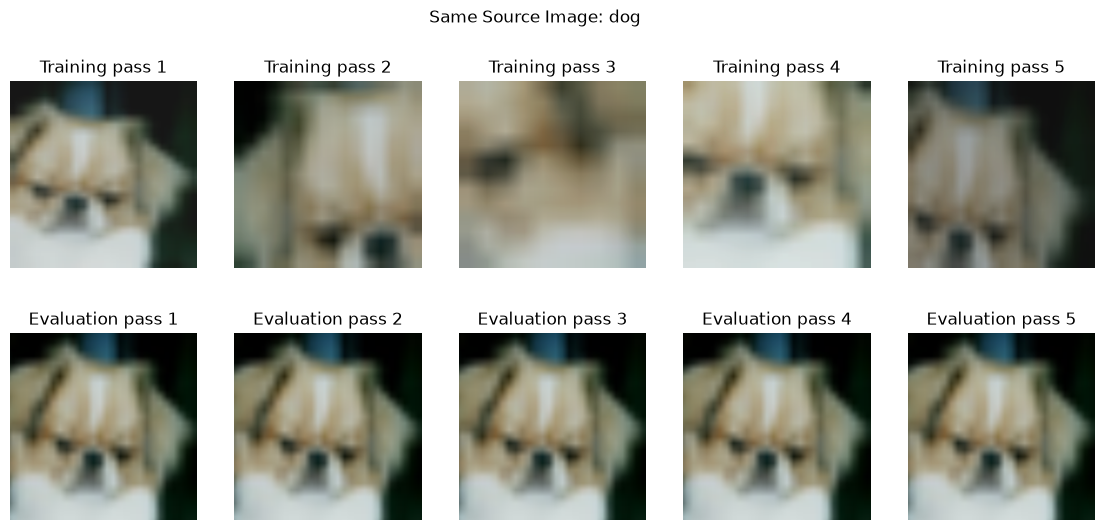

In [72]:
# Generate lists with training and evaluation passes
train_passes = [train_transform(source_image) for _ in range(5)]
eval_passes = [eval_transform(source_image) for _ in range(5)]

# Display training and evaluation passes
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i in range(5):
    axes[0, i].imshow(to_displayable(train_passes[i]))
    axes[0, i].set_title(f'Training pass {i + 1}')
    axes[0, i].axis("off")

    axes[1, i].imshow(to_displayable(eval_passes[i]))
    axes[1, i].set_title(f'Evaluation pass {i + 1}')
    axes[1, i].axis('off')

fig.suptitle(f'Same Source Image: {classes[source_label]}')

plt.show()

## 4. Training and Validation DataLoaders

Each subset uses its corresponding transformation pipeline. Both experiments use the same images, batch size, epoch count, and seeded shuffle sequence.

In [83]:
# Separate dataset objects allow different transforms for each subset
train_data = datasets.CIFAR10(root = './data', train = True, download = False, transform = train_transform)
val_data = datasets.CIFAR10(root = './data', train = True, download = False, transform = eval_transform)

# Apply the previously selected, non-overlapping indices
train_subset = Subset(train_data, train_indices.tolist())
val_subset = Subset(val_data, val_indices.tolist())

In [84]:
# Fresh loaders repeat the same shuffle sequence for each experiment
def make_loaders():
    generator = torch.Generator().manual_seed(42)
    train_loader = DataLoader(train_subset, batch_size = 16, shuffle = True, generator = generator, num_workers = 0)
    val_loader = DataLoader(val_subset, batch_size = 16, shuffle = False, num_workers = 0)

    return train_loader, val_loader

In [85]:
print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Batch size:", 16)
print("Epochs per experiment:", 5)

Training images: 1000
Validation images: 300
Batch size: 16
Epochs per experiment: 5


## 5. Pretrained Model Setup

- Now, an ImageNet-pretrained ResNet-18 is loaded and its final classification layer is replaced for the 10 CIFAR-10 classes.

- Both experiments start with identical pretrained weights and an identical new classification head.

- Feature extraction trains only the new head. Fine-tuning also updates the final residual stage, layer4, while keeping the earlier layers frozen.

- The backbone architecture remains unchanged apart from the final layer.

In [86]:
# Download pretrained weights into an ignored project folder
torch.hub.set_dir("./torch_cache")

In [87]:
# Load ResNet-18 with pretrained ImageNet weights
initial_model = models.resnet18(weights = models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all pretrained parameters
for parameter in initial_model.parameters():
    parameter.requires_grad = False

# Replace the original head with a trainable head for CIFAR-10
initial_model.fc = nn.Linear(initial_model.fc.in_features, num_classes)

# Copy the same starting weights for both experiments
feature_model = copy.deepcopy(initial_model)
fine_model = copy.deepcopy(initial_model)

# Allow the final residual stage to learn during fine-tuning
for parameter in fine_model.layer4.parameters():
    parameter.requires_grad = True

# Start in evaluation mode to preserve BatchNorm running statistics
feature_model.eval()
fine_model.eval()

feature_model = feature_model.to(device)
fine_model = fine_model.to(device)


In [90]:
# Count only parameters that are allowed to learn
def count_trainable(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
        )

In [91]:
# Print head layer and number of trainable parameters for each model
print('Head:', feature_model.fc)
print('Feature extraction trainable params:', count_trainable(feature_model))
print('Fine-tuning trainable params:', count_trainable(fine_model))

Head: Linear(in_features=512, out_features=10, bias=True)
Feature extraction trainable params: 5130
Fine-tuning trainable params: 8398858


## 6. Training and Evaluation Functions

- Both experiments use the same training and validation functions.

- During feature extraction, the backbone remains in evaluation mode while the classification head trains.

- During fine-tuning, layer4 and the head train while the earlier frozen layers remain in evaluation mode.

- Validation uses evaluation mode with gradient tracking disabled.

- Training time measures the training passes only, excluding validation and the initial download of pretrained weights.

In [104]:
# Set criterion and define shared functions
criterion = nn.CrossEntropyLoss()

In [ ]:
def synchronize_device():
    # Ensure GPU work finishes before reading the timer
    if device.type == "cuda":
        torch.cuda.synchronize(device)

In [106]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_images = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (outputs.argmax(dim = 1) == labels).sum().item()
            total_images += batch_size

    return (total_loss / total_images, total_correct / total_images)

In [107]:
def train_experiment(model, optimizer, fine_tuning = False):
    # Repeat the augmentation and shuffle sequences for each run
    train_loader, val_loader = make_loaders()

    history = []
    training_seconds = 0.0

    for epoch in range(5):
        # Keep all frozen layers, including BatchNorm, in eval mode
        model.eval()
        model.fc.train()

        if fine_tuning:
            model.layer4.train()

        total_loss = 0.0
        total_correct = 0
        total_images = 0

        synchronize_device()
        start = time.perf_counter()

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none = True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (outputs.argmax(dim = 1) == labels).sum().item()
            total_images += batch_size

        synchronize_device()
        training_seconds += time.perf_counter() - start

        train_loss = total_loss / total_images
        train_accuracy = total_correct / total_images

        val_loss, val_accuracy = evaluate(model, val_loader)

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'val_loss': val_loss,
            'val_accuracy': val_accuracy
            })

        print(f'Epoch {epoch + 1}/{5} | 'f'Train loss: {train_loss:.4f} | 'f'Train accuracy: {train_accuracy:.2%} | 'f'Val accuracy: {val_accuracy:.2%}', flush = True)

    return {
        "history": history,
        "val_accuracy": history[-1]["val_accuracy"],
        "training_seconds": training_seconds,
        "trainable_parameters": count_trainable(model)
        }

## 7. Feature Extraction Baseline

The new classification head is trained using `AdamW` with a learning rate of **0.001**. All pretrained backbone parameters remain frozen, and their BatchNorm running statistics remain unchanged. The experiment runs for five epochs using the predefined training and validation subsets.

In [ ]:
# Restore the starting model so re-running this cell starts a fresh experiment
feature_model = copy.deepcopy(initial_model).to(device)
feature_optimizer = torch.optim.AdamW(feature_model.fc.parameters(),lr = 0.001)

In [ ]:
# Run feature extraction
feature_results = train_experiment(feature_model, feature_optimizer, fine_tuning = False)

# Print extraction results
print('Feature Extraction Results')
print('Validation accuracy:', f'{feature_results["val_accuracy"]:.2%}')
print('Training time:', f'{feature_results['training_seconds']:.1f} seconds')
print('Trainable parameters:',f'{feature_results["trainable_parameters"]:,}')
print('Confirmed: frozen backbone weights and buffers are unchanged.')

Epoch 1/5 | Train loss: 1.8888 | Train accuracy: 36.50% | Val accuracy: 59.33%
Epoch 2/5 | Train loss: 1.3712 | Train accuracy: 55.10% | Val accuracy: 66.67%
Epoch 3/5 | Train loss: 1.1721 | Train accuracy: 62.90% | Val accuracy: 70.33%
Epoch 4/5 | Train loss: 1.0945 | Train accuracy: 63.10% | Val accuracy: 73.67%
Epoch 5/5 | Train loss: 1.0352 | Train accuracy: 66.90% | Val accuracy: 76.00%
Feature Extraction Results
Validation accuracy: 76.00%
Training time: 254.0 seconds
Trainable parameters: 5,130
Confirmed: frozen backbone weights and buffers are unchanged.


## 8. Fine-Tuning Comparison

Now let's start from the same initial model and unfreeze layer4 while keeping the earlier backbone layers frozen. One `AdamW` optimizer uses separate parameter groups: a learning rate of **0.001** for the classification head and **0.0001** for `layer4`. The dataset split, random seed, augmentation, batch size, and five-epoch training budget match the baseline.

In [113]:
# Restore the identical starting model
fine_model = copy.deepcopy(initial_model).to(device)

# Unfreeze only the final residual stage
for parameter in fine_model.layer4.parameters():
    parameter.requires_grad = True

# One optimizer with discriminative learning rates
fine_optimizer = torch.optim.AdamW([
    {"params": fine_model.fc.parameters(), "lr": 0.001},
    {"params": fine_model.layer4.parameters(), "lr": 0.0001}
    ])

print("Head learning rate:", 0.001)
print("Layer4 learning rate:", 0.0001)
print("Trainable parameters:", f"{count_trainable(fine_model):,}")

Head learning rate: 0.001
Layer4 learning rate: 0.0001
Trainable parameters: 8,398,858


In [114]:
# Run fine tuning
fine_results = train_experiment(fine_model, fine_optimizer, fine_tuning = True)

# Print fine tuning results
print('Fine-Tuning Results')
print('Validation accuracy:', f'{fine_results["val_accuracy"]:.2%}')
print('Training time:', f'{fine_results["training_seconds"]:.1f} seconds')
print('Trainable parameters:',f'{fine_results["trainable_parameters"]:,}')

Epoch 1/5 | Train loss: 1.5517 | Train accuracy: 45.80% | Val accuracy: 71.33%
Epoch 2/5 | Train loss: 0.9559 | Train accuracy: 65.70% | Val accuracy: 72.00%
Epoch 3/5 | Train loss: 0.8343 | Train accuracy: 71.30% | Val accuracy: 77.67%
Epoch 4/5 | Train loss: 0.7798 | Train accuracy: 71.90% | Val accuracy: 82.33%
Epoch 5/5 | Train loss: 0.6619 | Train accuracy: 77.50% | Val accuracy: 79.33%
Fine-Tuning Results
Validation accuracy: 79.33%
Training time: 487.1 seconds
Trainable parameters: 8,398,858


## 9. Results Comparison

Both experiments use identical initial weights, dataset splits, random seeds, augmentation pipelines, batch sizes, and epoch counts. The table reports validation accuracy after the fifth epoch, training time excluding validation, and the number of trainable parameters.

In [120]:
# Create comparison table with Pandas DataFrame
comparison = pd.DataFrame([
    {'Approach': 'Feature extraction',
    'Validation accuracy (%)': feature_results['val_accuracy'] * 100,
    'Training time (seconds)': feature_results['training_seconds'],
    'Trainable parameters': feature_results['trainable_parameters']
    },
    {'Approach': 'Fine-tuning',
    'Validation accuracy (%)': fine_results['val_accuracy'] * 100,
    'Training time (seconds)': fine_results['training_seconds'],
    'Trainable parameters': fine_results['trainable_parameters']
    }
])

# Display result
comparison.round(2)

,Approach,Validation accuracy (%),Training time (seconds),Trainable parameters
0,Feature extraction,76.00,253.95,5130
1,Fine-tuning,79.33,487.10,8398858


Fine-tuning achieved **79.33%** validation accuracy versus **76.00%** for feature extraction. Updating layer4 allowed the pretrained features to adapt to CIFAR-10, while feature extraction only trained the classification head. This improvement required approximately **1.92** times the training time.